# Project 2: Telco Customer Churn Classification Model

This project uses the **Telco Customer Churn dataset** from Kaggle, which contains information on 7,043 telecom customers including demographics, account details, and subscribed services. The goal is to build and evaluate a **Logistic Regression classification model** that can predict whether a customer will churn (leave the company) based on these features. By exploring the data, applying preprocessing, and training the model, we aim to identify the factors most strongly associated with churn and assess how well Logistic Regression can anticipate customer behavior. This analysis not only demonstrates technical modeling skills but also provides business-relevant insights into customer retention strategies.

### Dataset Source

The data for this project comes from Kaggle:  
[Telco Customer Churn Dataset](https://www.kaggle.com/datasets/blastchar/telco-customer-churn)


### Import Necessary Packages

In [81]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
    RocCurveDisplay, PrecisionRecallDisplay
)
from sklearn.linear_model import LogisticRegression
from matplotlib.ticker import PercentFormatter


RANDOM_STATE = 42


### Read in the Data

In [82]:
# Load the Telco Customer Churn dataset
df = pd.read_csv("/Users/kathrynkopczenski/Downloads/WA_Fn-UseC_-Telco-Customer-Churn.csv")

# Display shape and first few rows
print("Dataset shape:", df.shape)
df.head()

Dataset shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


### Preprocessing/Data Cleaning

Before modeling, we need to prepare the dataset for analysis.  
- The `TotalCharges` column is stored as text and must be converted to numeric. When converted, 11 missing values appear, which all correspond to customers with `tenure = 0` (brand-new customers). Since these customers have not accumulated charges yet, we safely replace those missing values with 0.  
- The `customerID` column is only an identifier and provides no predictive value, so it will be dropped.  
- Finally, the target variable `Churn` will be encoded as 0 (No) and 1 (Yes) to make it suitable for classification.


### Convert `TotalCharges` to numeric and handle missing values



In [83]:
# Convert TotalCharges to numeric (coerce blanks to NaN)
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

# Safety check: missing TotalCharges should only occur when tenure=0
assert (df["TotalCharges"].isna() == (df["tenure"] == 0)).all(), \
    "Found unexpected missing values in TotalCharges!"

# Fill missing TotalCharges with 0 (valid for tenure=0 customers)
df["TotalCharges"] = df["TotalCharges"].fillna(0)

# Verify no more missing values
print("Missing values after fix:")
print(df.isna().sum().sort_values(ascending=False).head())


Missing values after fix:
customerID          0
DeviceProtection    0
TotalCharges        0
MonthlyCharges      0
PaymentMethod       0
dtype: int64


### Drop `customerID` column and encode target

In [84]:
# Drop customerID since it’s just an identifier
if "customerID" in df.columns:
    df = df.drop(columns=["customerID"])

# Encode target variable: Churn -> {0,1}
df["Churn"] = df["Churn"].apply(lambda x: 1 if x.strip().lower() == "yes" else 0)

# Quick check
df[["tenure", "MonthlyCharges", "TotalCharges", "Churn"]].head()


,tenure,MonthlyCharges,TotalCharges,Churn
0,1,29.85,29.85,0
1,34,56.95,1889.50,0
2,2,53.85,108.15,1
3,45,42.30,1840.75,0
4,2,70.70,151.65,1


### Exploratory Data Analysis (EDA)

Before building a model, it is important to explore the dataset and visualize patterns related to churn.  
We will examine:
- The overall churn rate (class balance).  
- Distributions of numeric variables such as tenure, MonthlyCharges, and TotalCharges.  
- Churn rates across important categorical features like Contract type, PaymentMethod, and InternetService.  

These visualizations help us understand which factors might influence churn and guide the modeling process.


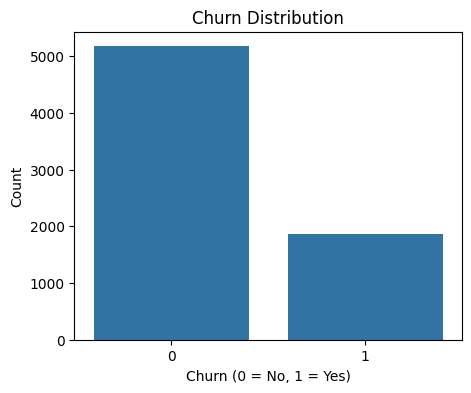

Overall churn rate: 26.54%


In [85]:
# Churn distribution
plt.figure(figsize=(5,4))
sns.countplot(data=df, x="Churn")
plt.title("Churn Distribution")
plt.xlabel("Churn (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.show()

churn_rate = df["Churn"].mean()
print(f"Overall churn rate: {churn_rate:.2%}")

#### Numeric Distributions by Churn

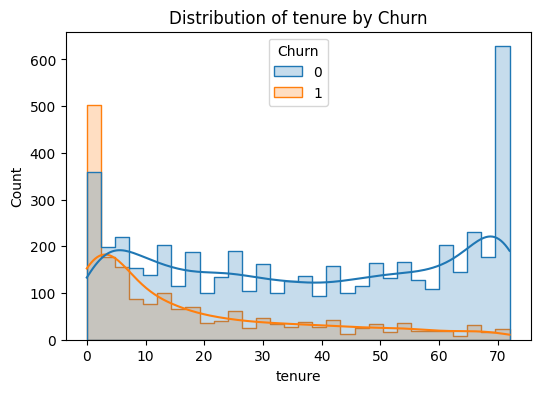

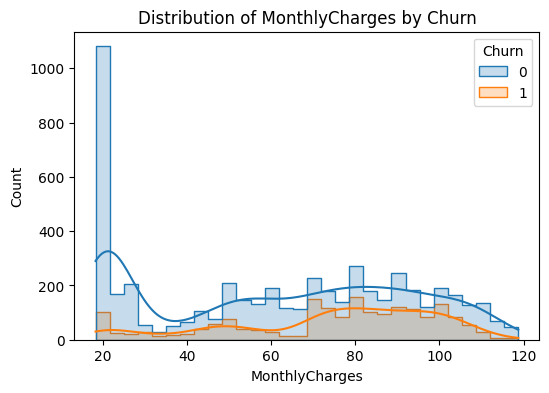

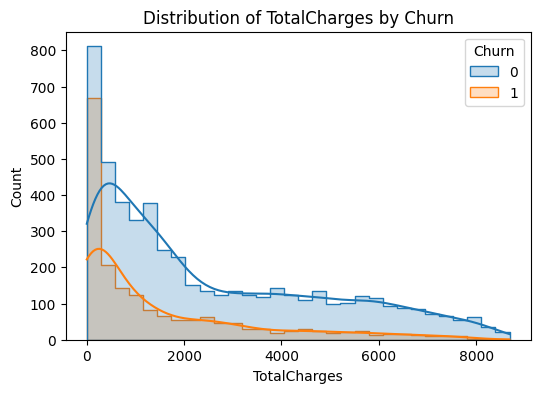

In [86]:
numeric_cols = ["tenure", "MonthlyCharges", "TotalCharges"]

for col in numeric_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(data=df, x=col, hue="Churn", bins=30, kde=True, element="step")
    plt.title(f"Distribution of {col} by Churn")
    plt.show()


### Combining Numeric Distributions

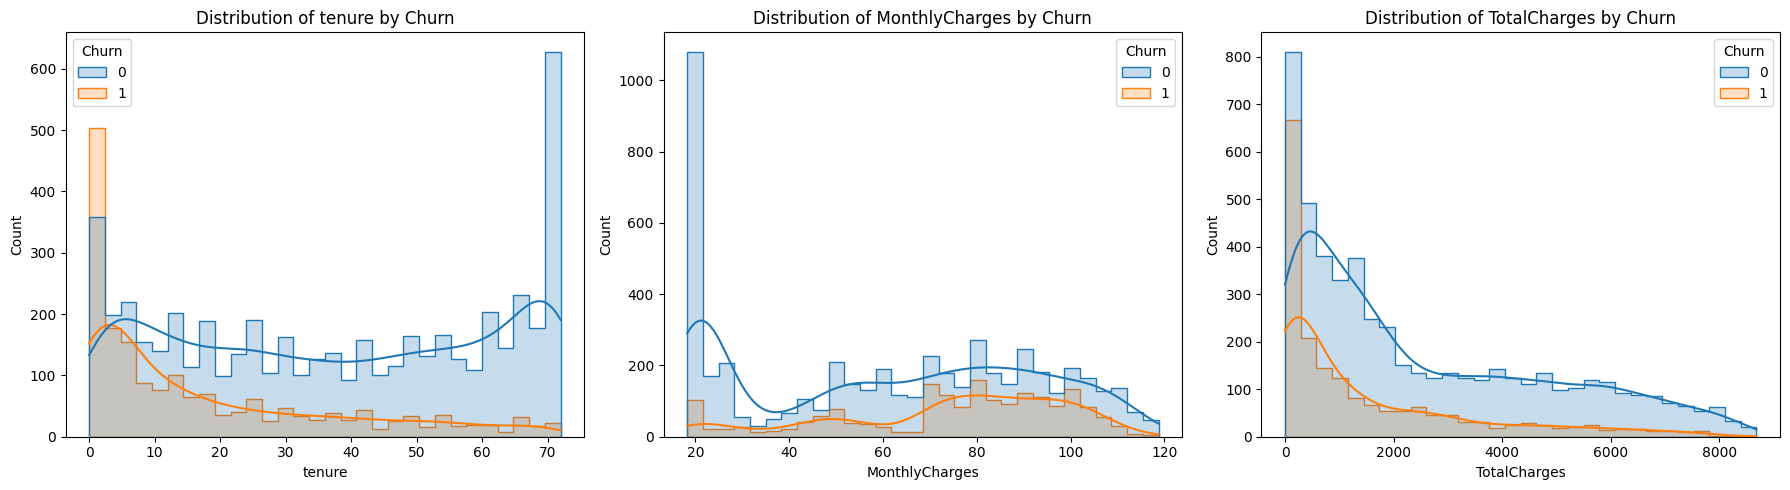

In [87]:
# Numeric columns to visualize
numeric_cols = ["tenure", "MonthlyCharges", "TotalCharges"]

# Create subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=False)

for i, col in enumerate(numeric_cols):
    sns.histplot(data=df, x=col, hue="Churn", bins=30, kde=True, element="step", ax=axes[i])
    axes[i].set_title(f"Distribution of {col} by Churn")

plt.tight_layout()
plt.show()

#### Categorical Churn Rates

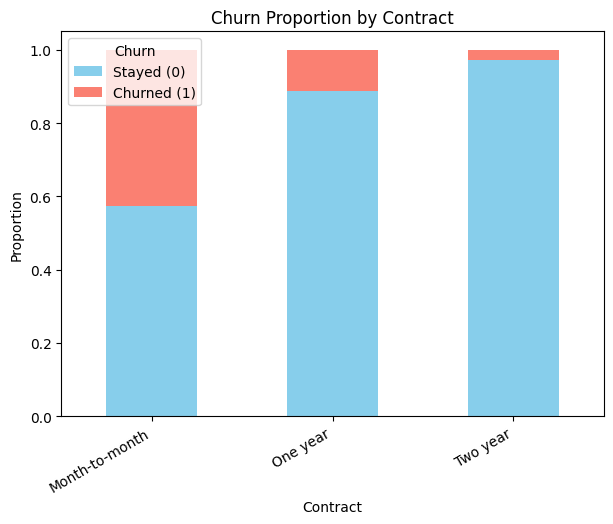

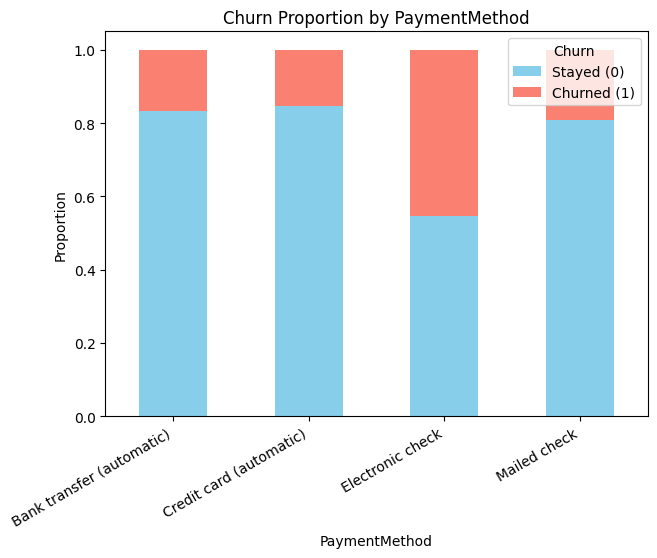

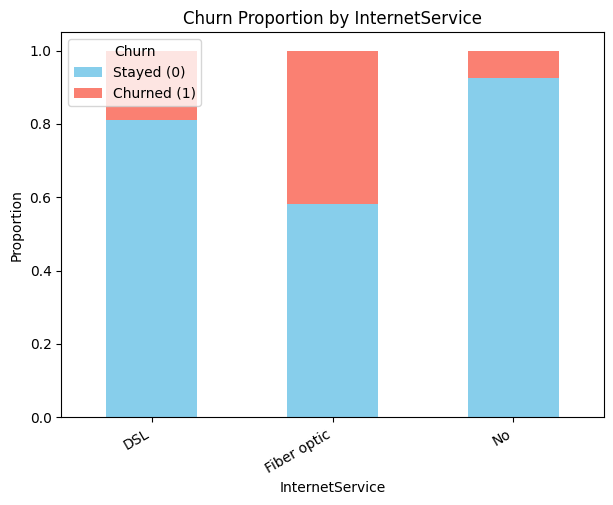

In [88]:
for col in categorical_cols:
    churn_crosstab = pd.crosstab(df[col], df["Churn"], normalize="index")
    ax = churn_crosstab.plot(kind="bar", stacked=True, color=["skyblue", "salmon"], figsize=(7,5))
    ax.set_title(f"Churn Proportion by {col}")
    ax.set_ylabel("Proportion")
    ax.set_xlabel(col)
    ax.legend(["Stayed (0)", "Churned (1)"], title="Churn")
    plt.xticks(rotation=30, ha="right")
    plt.show()


### Combined Categorical Churn Rates

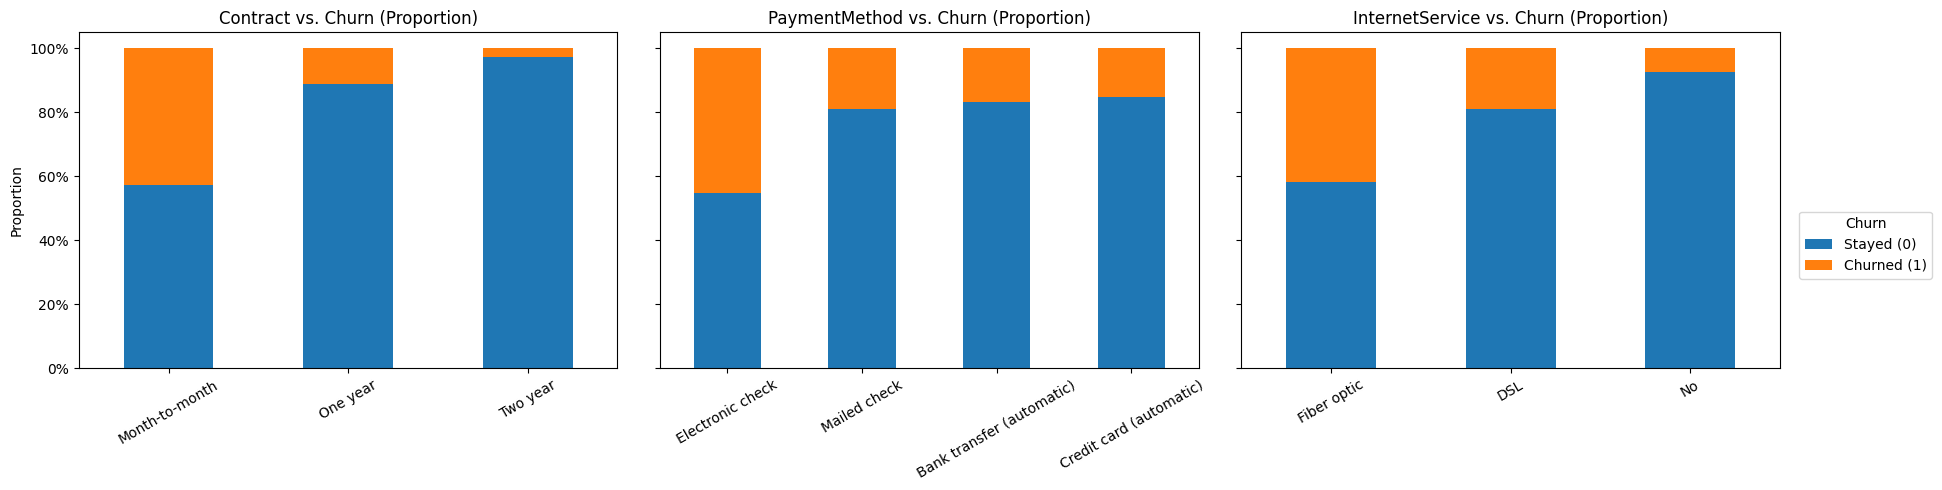

In [89]:
cats = ["Contract", "PaymentMethod", "InternetService"]

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

for i, col in enumerate(cats):
    # Proportion of churn (columns 0=Stayed, 1=Churned) within each category
    ct = pd.crosstab(df[col], df["Churn"], normalize="index").sort_values(1, ascending=False)

    # Stacked bar in the assigned subplot
    ax = ct.plot(kind="bar", stacked=True, ax=axes[i], legend=False)

    ax.set_title(f"{col} vs. Churn (Proportion)")
    ax.set_ylabel("Proportion")
    ax.yaxis.set_major_formatter(PercentFormatter(1.0))
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=30, labelrotation=30)

# One legend for all three on the right
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, ["Stayed (0)", "Churned (1)"], title="Churn", loc="center right", bbox_to_anchor=(1.08, 0.5))

plt.tight_layout()
plt.show()


### Correlation Heatmap (Numeric Features)

Correlation analysis helps us see linear relationships between numeric variables and churn.  
For example, we expect `tenure` to be **negatively correlated** with churn (shorter tenure → higher churn) and `TotalCharges` to be positively correlated with `tenure` but less directly with churn.


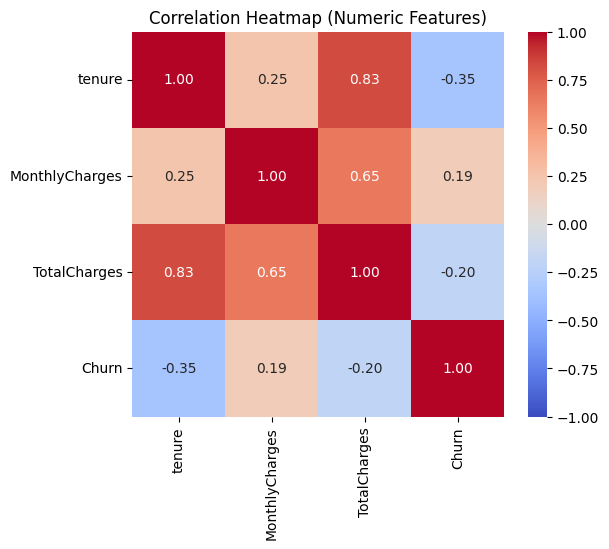

In [90]:
# Correlation heatmap for numeric features
plt.figure(figsize=(6,5))
corr = df[["tenure", "MonthlyCharges", "TotalCharges", "Churn"]].corr()

sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", vmin=-1, vmax=1)
plt.title("Correlation Heatmap (Numeric Features)")
plt.show()


### Correlation Heatmap Results

The correlation heatmap highlights relationships among numeric features and churn:

- **Tenure vs. Churn (-0.35)**: Customers with shorter tenures are more likely to churn, confirming that newer customers are at higher risk.  
- **MonthlyCharges vs. Churn (+0.19)**: Higher monthly bills show a weak positive correlation with churn, suggesting that more expensive plans may contribute to dissatisfaction.  
- **TotalCharges vs. Churn (-0.20)**: Total charges have a weak negative correlation with churn, likely because this value is strongly tied to tenure (longer-tenured customers accumulate higher total charges and are less likely to leave).  
- **Feature Relationships**: Tenure and TotalCharges are very strongly correlated (+0.83), while MonthlyCharges is moderately correlated with TotalCharges (+0.65).  

Overall, the heatmap confirms that **tenure** is the most influential numeric feature related to churn, followed by weaker but still relevant signals from **charges**.


### Categorical Feature Visualizations

To better understand churn patterns, we visualize how different categories relate to churn.  
Stacked bar charts show the proportion of customers who churned versus stayed within each category. This helps highlight high-risk groups (e.g., customers on month-to-month contracts).


<Figure size 700x500 with 0 Axes>

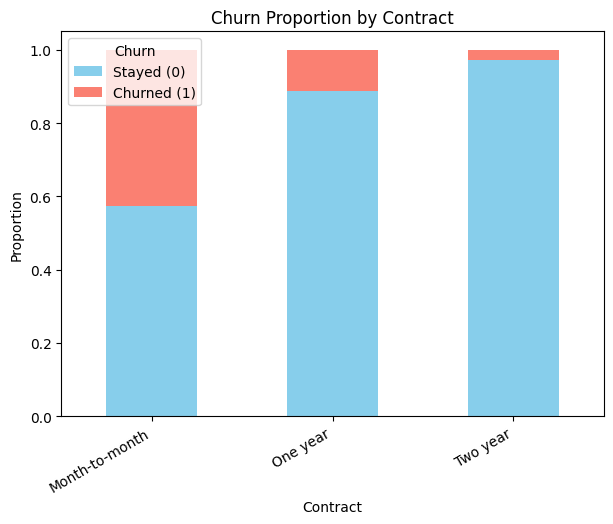

<Figure size 700x500 with 0 Axes>

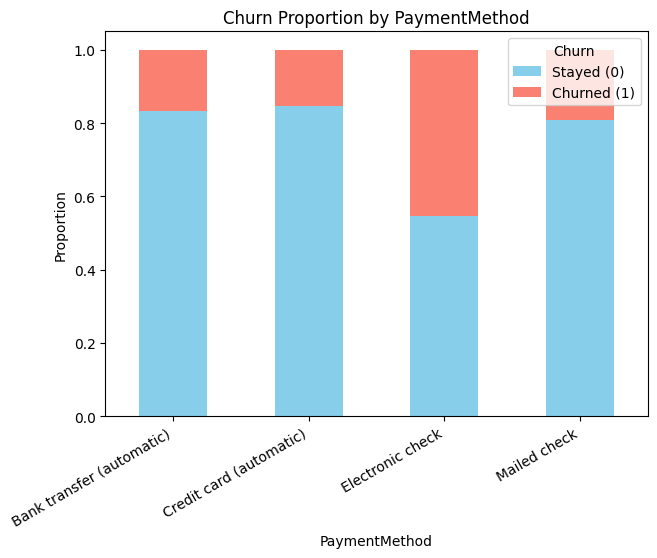

<Figure size 700x500 with 0 Axes>

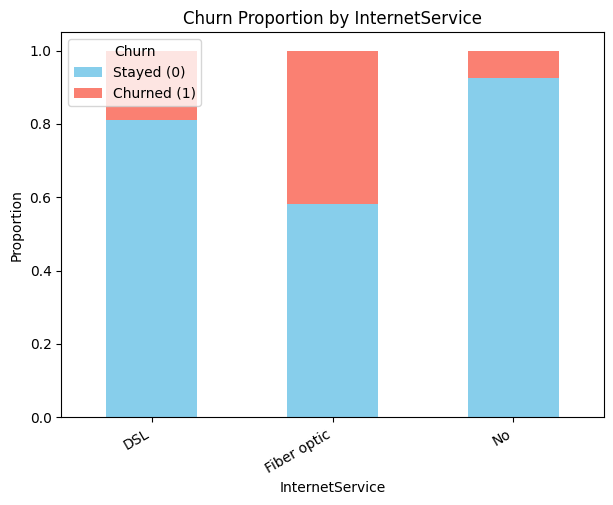

In [91]:
categorical_cols = ["Contract", "PaymentMethod", "InternetService"]

for col in categorical_cols:
    plt.figure(figsize=(7,5))
    churn_crosstab = pd.crosstab(df[col], df["Churn"], normalize="index")
    churn_crosstab.plot(kind="bar", stacked=True, color=["skyblue", "salmon"], figsize=(7,5))
    plt.title(f"Churn Proportion by {col}")
    plt.ylabel("Proportion")
    plt.xlabel(col)
    plt.legend(["Stayed (0)", "Churned (1)"], title="Churn")
    plt.xticks(rotation=30, ha="right")
    plt.show()


### Train/Test Split & Preprocessing for Logistic Regression

Before training our classification model, we need to split the dataset and preprocess the features:

- **Train/Test Split**: We divide the dataset into a training set (used to fit the model) and a test set (used only for final evaluation). We use stratification so the proportion of churn vs. non-churn customers remains the same in both sets.  
- **Numeric Features (Scaling)**: Logistic Regression works best when numeric variables are on a similar scale. We apply **StandardScaler**, which transforms values to have mean = 0 and standard deviation = 1.  
- **Categorical Features (Encoding)**: Since models can’t handle text categories directly, we use **One-Hot Encoding** to turn each category into a new binary column (e.g., “Contract = Month-to-month” becomes 1 if true, 0 otherwise).  
- **ColumnTransformer**: This lets us apply different preprocessing steps to numeric and categorical columns in a single, unified pipeline.


In [92]:
# Features / target
X = df.drop(columns=["Churn"])
y = df["Churn"]

# Train/test split (stratify to preserve churn rate)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# Identify column types
numeric_features = X_train.select_dtypes(include=["number"]).columns.tolist()
categorical_features = X_train.select_dtypes(exclude=["number"]).columns.tolist()

# Preprocess: scale numeric, one-hot encode categorical
preprocess = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
    ]
)

numeric_features, categorical_features


(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges'],
 ['gender',
  'Partner',
  'Dependents',
  'PhoneService',
  'MultipleLines',
  'InternetService',
  'OnlineSecurity',
  'OnlineBackup',
  'DeviceProtection',
  'TechSupport',
  'StreamingTV',
  'StreamingMovies',
  'Contract',
  'PaperlessBilling',
  'PaymentMethod'])

### Build the Logistic Regression Pipeline

We will combine our preprocessing (scaling numeric features and encoding categorical ones) with the Logistic Regression model in a single pipeline. This ensures all steps are applied consistently during training and testing. We also use `class_weight='balanced'` so the model adjusts for the imbalance between churn and non-churn customers.


In [93]:
# Build pipeline
logreg_clf = Pipeline(steps=[
    ("prep", preprocess),
    ("clf", LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42))
])

# Train the model
logreg_clf.fit(X_train, y_train)


,steps,"[('prep', ...), ('clf', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


### Make Predictions

Now that the model is trained, we can use it to make predictions on the test set.  
We generate both the predicted classes (0 = No Churn, 1 = Yes Churn) and predicted probabilities (useful for ROC and Precision–Recall curves).


In [94]:
# Predictions
y_pred = logreg_clf.predict(X_test)

# Predicted probabilities (for ROC/PR curves)
y_proba = logreg_clf.predict_proba(X_test)[:, 1]


### Evaluate Model Performance

We evaluate our Logistic Regression model using multiple metrics:
- **Accuracy**: Overall correctness  
- **Precision**: Of those predicted to churn, how many actually did  
- **Recall**: Of those who churned, how many we correctly identified  
- **F1-score**: Balance of precision and recall  
- **ROC AUC**: Ability to distinguish churn vs. non-churn across thresholds  
We also print a classification report and confusion matrix.


In [95]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    classification_report, confusion_matrix
)

# Metrics
acc  = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, zero_division=0)
rec  = recall_score(y_test, y_pred, zero_division=0)
f1   = f1_score(y_test, y_pred, zero_division=0)
auc  = roc_auc_score(y_test, y_proba)

print(f"Accuracy : {acc:.3f}")
print(f"Precision: {prec:.3f}")
print(f"Recall   : {rec:.3f}")
print(f"F1-score : {f1:.3f}")
print(f"ROC AUC  : {auc:.3f}\n")

print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=["No Churn","Churn"], zero_division=0))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))


Accuracy : 0.738
Precision: 0.504
Recall   : 0.783
F1-score : 0.614
ROC AUC  : 0.842

Classification Report:
              precision    recall  f1-score   support

    No Churn       0.90      0.72      0.80      1035
       Churn       0.50      0.78      0.61       374

    accuracy                           0.74      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.80      0.74      0.75      1409

Confusion Matrix:
[[747 288]
 [ 81 293]]


### Visualize Performance

To better understand the trade-offs of our model, we plot:
- **ROC Curve**: Shows performance across all thresholds (sensitivity vs. 1-specificity).  
- **Precision–Recall Curve**: Especially useful when dealing with imbalanced classes like churn.


<Figure size 640x480 with 0 Axes>

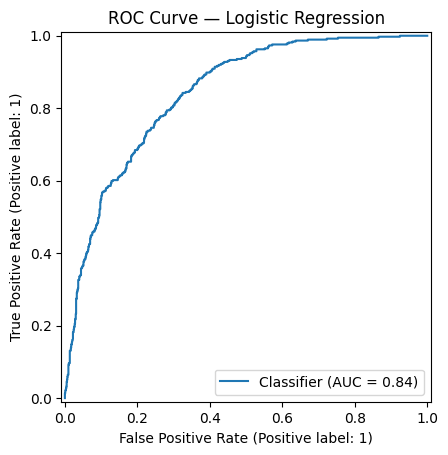

<Figure size 640x480 with 0 Axes>

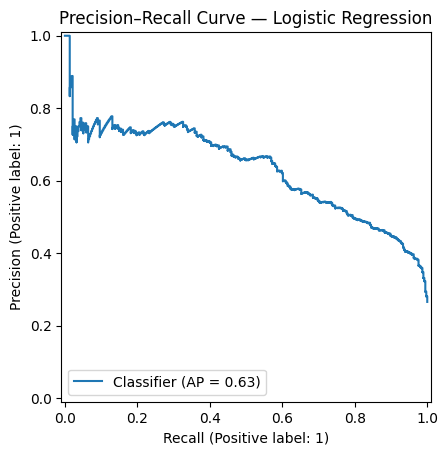

In [96]:
# ROC Curve
plt.figure()
RocCurveDisplay.from_predictions(y_test, y_proba)
plt.title("ROC Curve — Logistic Regression")
plt.show()

# Precision–Recall Curve
plt.figure()
PrecisionRecallDisplay.from_predictions(y_test, y_proba)
plt.title("Precision–Recall Curve — Logistic Regression")
plt.show()


### Combining ROC Curve and Precision-Recall Curve Visualization

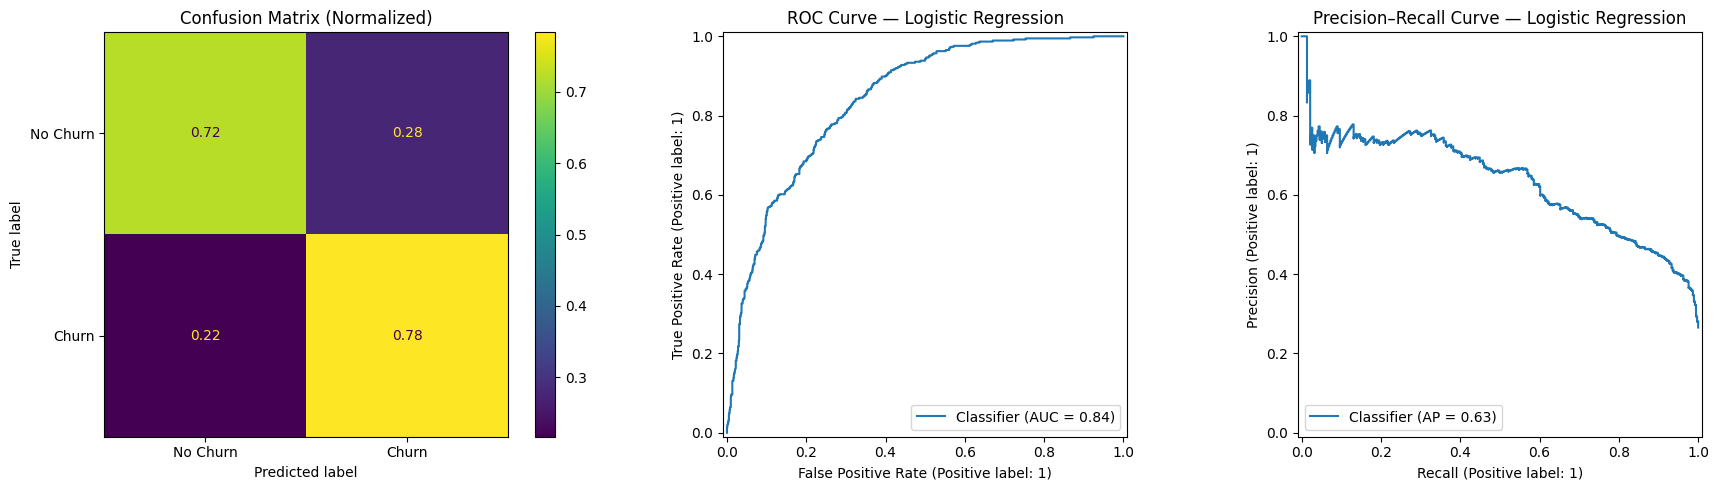

Saved: model_eval_triptych.png


In [97]:
import matplotlib.pyplot as plt
from sklearn.metrics import (
    ConfusionMatrixDisplay, RocCurveDisplay, PrecisionRecallDisplay
)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1) Confusion Matrix (normalized for easy reading)
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=["No Churn", "Churn"],
    normalize="true",
    ax=axes[0]
)
axes[0].set_title("Confusion Matrix (Normalized)")

# 2) ROC Curve
RocCurveDisplay.from_predictions(
    y_test, y_proba, ax=axes[1]
)
axes[1].set_title("ROC Curve — Logistic Regression")

# 3) Precision–Recall Curve
PrecisionRecallDisplay.from_predictions(
    y_test, y_proba, ax=axes[2]
)
axes[2].set_title("Precision–Recall Curve — Logistic Regression")

plt.tight_layout()
plt.savefig("model_eval_triptych.png", dpi=300, bbox_inches="tight")
plt.show()

print("Saved: model_eval_triptych.png")


### Model Evaluation Results

The Logistic Regression model shows solid performance in predicting customer churn:

- **ROC Curve (AUC = 0.84)**: This indicates the model has strong ability to distinguish between churn and non-churn customers. An AUC of 0.84 means that in 84% of random customer pairs (one churner, one non-churner), the model assigns a higher churn probability to the actual churner.  
- **Precision–Recall Curve (AP = 0.63)**: Precision and recall are more informative for imbalanced datasets like this one, where only about 26% of customers churn. The average precision of 0.63 shows the model maintains a reasonable balance: it correctly identifies a good portion of churners, though precision drops when recall increases toward 1.  
- **Trade-off Insight**: If the business wants to **minimize missed churners**, a higher recall threshold can be chosen (accepting more false positives). If the goal is to **target fewer customers with higher certainty**, the threshold can be adjusted to improve precision.

Overall, Logistic Regression provides meaningful predictive power and actionable insights, though there is room for improvement with more complex models or threshold tuning.
